# Ampiezze impulso CLEAR





In [1]:
import Pkg
Pkg.add(["DifferentialEquations", "Plots", "LaTeXStrings"])

   Resolving package versions...
     Project No packages added to or removed from `C:\Users\alice\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\alice\.julia\environments\v1.12\Manifest.toml`


In [8]:
using DifferentialEquations
using Plots
using LaTeXStrings
using TOML

project_dir = pwd()
include(joinpath(project_dir, "funz", "CLEAR_Reset.jl"))

using .CLEAR_Reset

# 1. Caricamento parametri


In [10]:
par = TOML.parsefile(joinpath(project_dir, "parametri", "risonatore.toml"))

kappa = par["kappa"]
detuning = par["detuning"]
chi = par["chi"]
alpha0 = par["alpha0_real"] + im * par["alpha0_imag"]
t_kick = par["t_kick"]
t_readout = par["t_readout"]
n_target = par["n_target"]

params = ResonatorParams(kappa, detuning; alpha0=alpha0, chi=chi)

# Il drive è scelto in modo che, per detuning ±χ, la popolazione stazionaria
# sia circa n_target. Con detuning base nullo:
# n_ss = |A|^2 / ((κ/2)^2 + χ^2)
A_readout = sqrt(n_target * ((kappa / 2)^2 + chi^2))

println("Parametri caricati")
println("kappa = ", kappa)
println("chi = ", chi)
println("t_kick = ", t_kick)
println("t_readout = ", t_readout)
println("A_readout = ", A_readout)


LoadError: UndefVarError: `ResonatorParams` not defined in `Main`
Hint: It looks like two or more modules export different bindings with this name, resulting in ambiguity. Try explicitly importing it from a particular module, or qualifying the name with the module it should come from.

# 2. Ampiezze impulso CLEAR


In [5]:
comparison = compare_rect_CLEAR(
    params;
    A=A_readout,
    t_kick=t_kick,
    t_readout=t_readout,
    saveat_points=2000,
)

println("\nAmpiezze CLEAR calcolate dal modello lineare")
println("ringup1   = ", comparison.kicks.ringup1)
println("ringup2   = ", comparison.kicks.ringup2)
println("readout   = ", comparison.kicks.readout)
println("ringdown1 = ", comparison.kicks.ringdown1)
println("ringdown2 = ", comparison.kicks.ringdown2)

println("\nDurate")
println("t_rect_stop = ", comparison.t_rect_stop)
println("t_total     = ", comparison.t_total)



Ampiezze CLEAR calcolate dal modello lineare
ringup1   = 17.691606438659946 - 1.7763568394002505e-15im
ringup2   = 10.55422374165674 + 4.440892098500626e-16im
readout   = 16.827913996572953 + 0.0im
ringdown1 = -0.8636924420869931 - 1.1102230246251565e-16im
ringdown2 = 6.273690254916212 + 2.220446049250313e-16im

Durate
t_rect_stop = 0.8999999999999999
t_total     = 1.2


# 4. Grafici


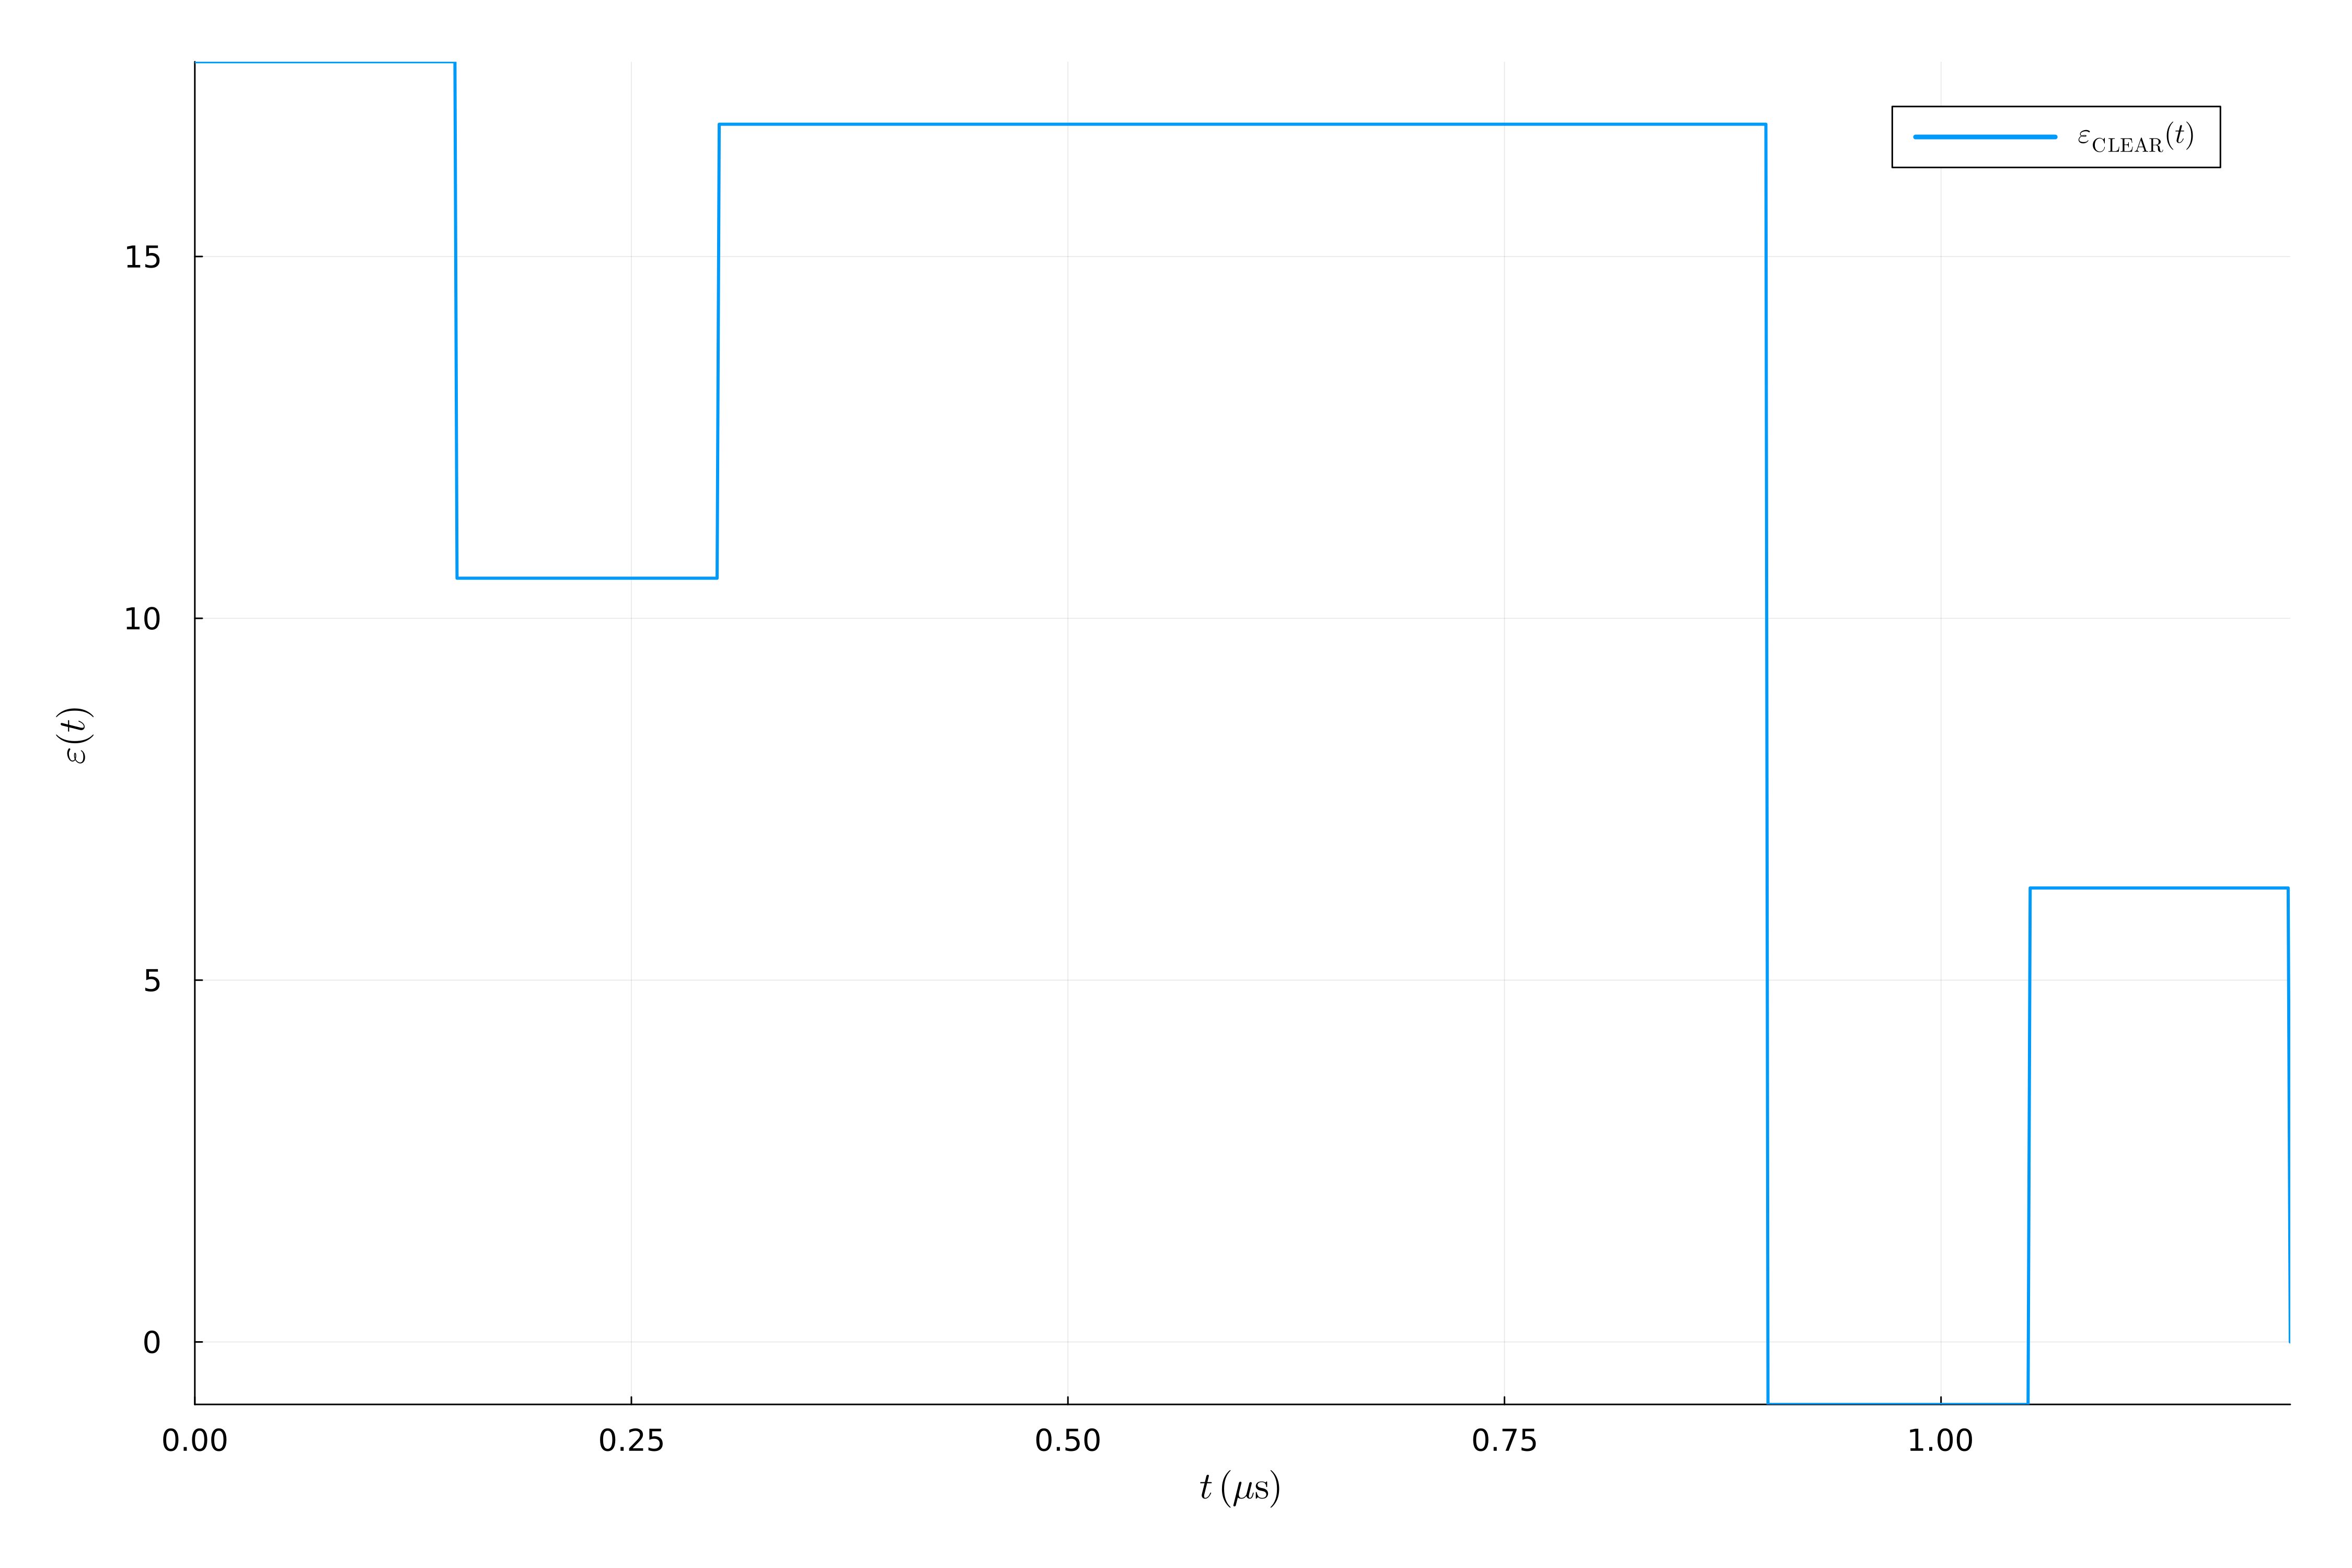

In [7]:
plt_pulse_clear = plot_epsilon_clear(
    params,
    t_kick,
    t_readout,
    A_readout,
)

display(plt_pulse_clear)


